In [1]:
# external
import numpy as np, healpy as hp
from matplotlib.pyplot import *
# modules from cmblensplus
from cmblensplus import basic, curvedsky as cs
from cmblensplus.utils import constant as c, cmb

In [2]:
Lmax = 1024*2
# ucl is an array of shape [0:5,0:rlmax+1] and ucl[0,:] = TT, ucl[1,:] = EE, ucl[2,:] = TE, lcl[3,:] = phiphi, lcl[4,:] = Tphi
lcl = cmb.read_camb_cls('../data/lensedcls.dat',ftype='lens',output='array')[:,:Lmax+1]

In [3]:
alm = cs.utils.gaussTEB(lcl[0,:],lcl[1,:],lcl[2,:],lcl[3,:])

In [4]:
Tmap = cs.utils.hp_alm2map(1024,alm[0])

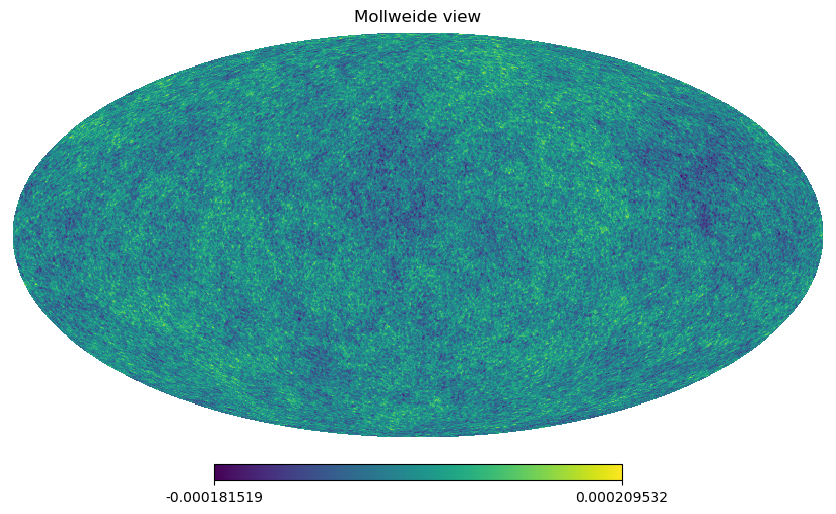

In [5]:
hp.mollview(Tmap)

In [6]:
Talm = cs.utils.hp_map2alm(Lmax,Lmax,Tmap)

In [7]:
cl = cs.utils.alm2cl(Talm)

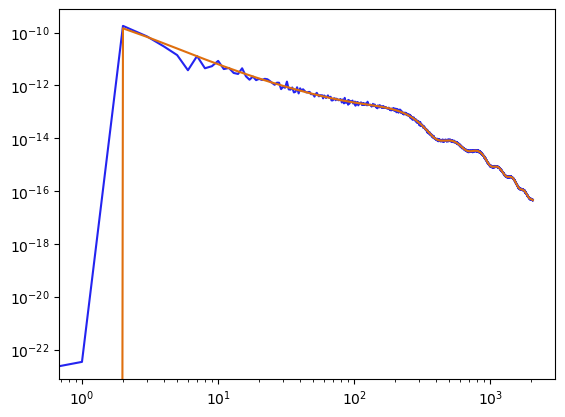

In [8]:
loglog(cl)
loglog(lcl[0])

In [9]:
QU = cs.utils.hp_alm2map_spin(1024,2,alm[1],alm[2])

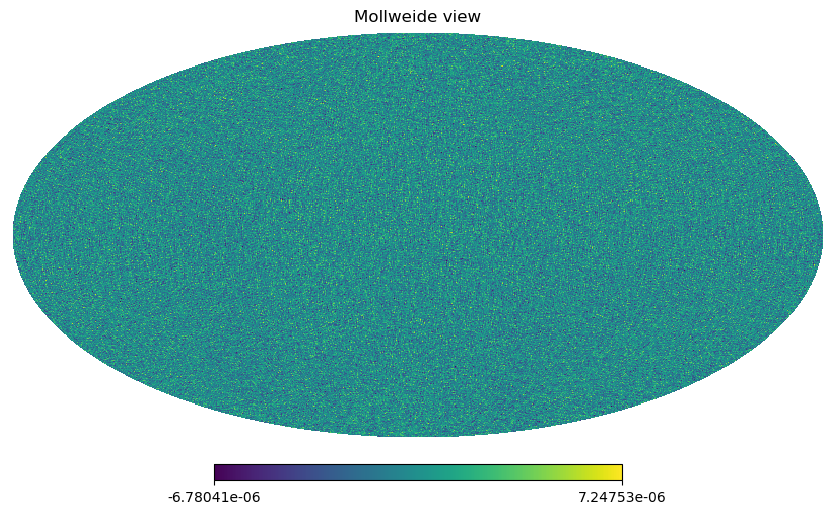

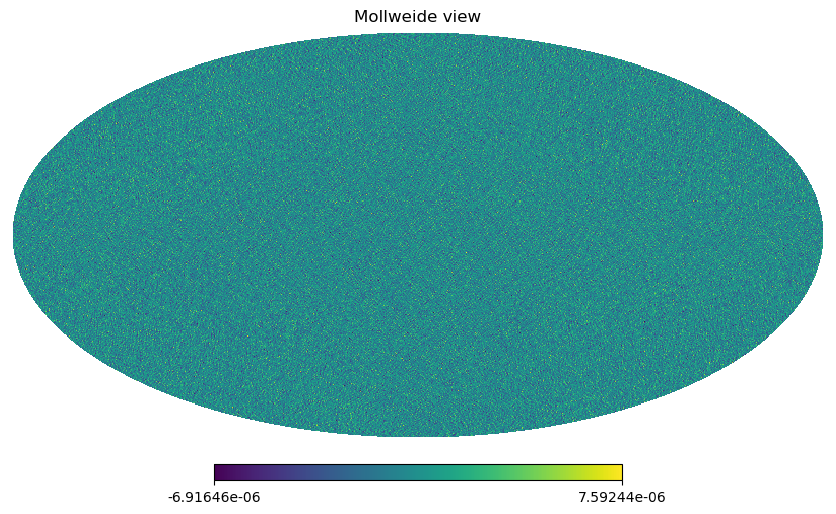

In [10]:
hp.mollview(QU[0])
hp.mollview(QU[1])

In [11]:
Elm, Blm = cs.utils.hp_map2alm_spin(Lmax,Lmax,2,QU[0],QU[1])

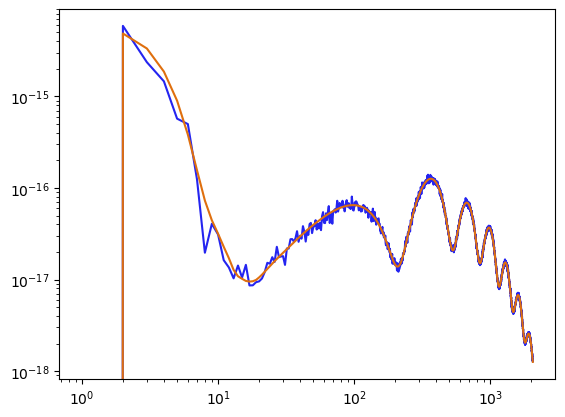

In [12]:
EE = cs.utils.alm2cl(Elm)
loglog(EE)
loglog(lcl[1])

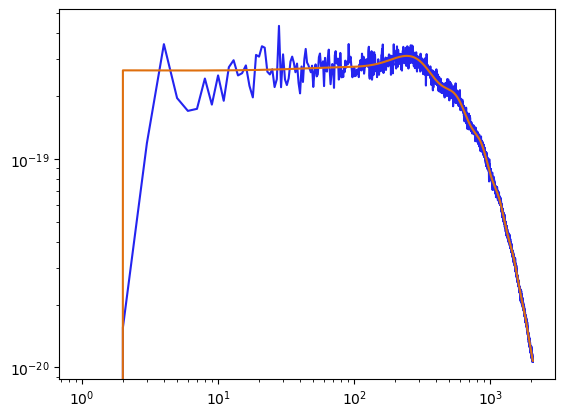

In [13]:
BB = cs.utils.alm2cl(Blm)
loglog(BB)
loglog(lcl[2])